# Model Training

## Baseline Training

### Import Libraries

In [32]:
import os
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

os.makedirs("../models", exist_ok=True)
os.makedirs("../visualizations", exist_ok=True)

sns.set_style("whitegrid")

### Load Dataset

In [33]:
df = pd.read_csv("../data/traffic_featured.csv")

print(df.shape)

df.head()

(120000, 25)


,timestamp,hour,day_of_week,geohash_location,road_type,num_lanes,traffic_signals,large_vehicles_count,temperature,humidity,...,event_Concert,event_Conference,event_Festival,event_Sports_Event,peak_hour_flag,weekend_flag,rush_hour_indicator,signal_density,weather_impact_score,traffic_density_score
0,2023-01-01 00:00:00,0,6,38,4,3,0.817106,-1.415303,-0.912469,0.113391,...,False,False,False,False,0,1,0,0.272369,0.247931,0.040868
1,2023-01-01 00:05:00,0,6,28,0,5,-1.223831,0.706767,-0.927065,0.834313,...,False,False,True,False,0,1,0,-0.244766,0.290970,0.146096
2,2023-01-01 00:10:00,0,6,14,3,3,-1.223831,0.353089,-0.994952,-0.006479,...,False,False,False,False,0,1,0,-0.407944,0.233829,0.075041
3,2023-01-01 00:15:00,0,6,42,3,4,0.817106,0.706767,-1.580376,0.593531,...,False,False,False,False,0,1,0,0.204277,0.222750,0.072973
4,2023-01-01 00:20:00,0,6,7,0,4,0.817106,-0.707946,-1.056254,-0.559013,...,False,False,False,False,0,1,0,0.204277,0.194912,0.078544


### Create Features And Target

In [34]:
X = df.drop(columns=[
    "traffic_demand",
    "traffic_density_score",  # Excluded to prevent target leakage
    "timestamp"
])

y = df["traffic_demand"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (120000, 22)
Target Shape : (120000,)


In [35]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "../models/feature_columns.pkl"
)


['../models/feature_columns.pkl']

### Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(96000, 22)
(24000, 22)


### Random Forest

In [37]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

### XGBoost

In [38]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

### LightGBM

In [39]:
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=64,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgb_pred = lgbm.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1189
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 22
[LightGBM] [Info] Start training from score 802.402849


### Evaluation Function

In [40]:
def evaluate_model(name, y_true, y_pred):

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(y_true, y_pred)

    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return {
        "Model": name,
        "R² Score": round(r2,4),
        "RMSE": round(rmse,2),
        "MAE": round(mae,2),
        "MAPE": round(mape,2)
    }

### Comparison Table

In [41]:
results = []

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgb_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,R² Score,RMSE,MAE,MAPE
0,Random Forest,0.9207,177.60,115.47,16.06
1,XGBoost,0.9474,144.67,95.82,13.08
2,LightGBM,0.9483,143.41,94.77,12.99


## Model Visualization

### Feature Importance Function

In [ ]:
def plot_feature_importance(model, feature_names, model_name):

    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    importance = (
        importance
        .sort_values(by="Importance", ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importance,
        x="Importance",
        y="Feature"
    )

    plt.title(f"{model_name} - Top 15 Feature Importance")

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.tight_layout()

    filename = (
        f"../visualizations/"
        f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    )

    plt.savefig(filename, dpi=300)

    plt.show()


### Generate Feature Importance Charts

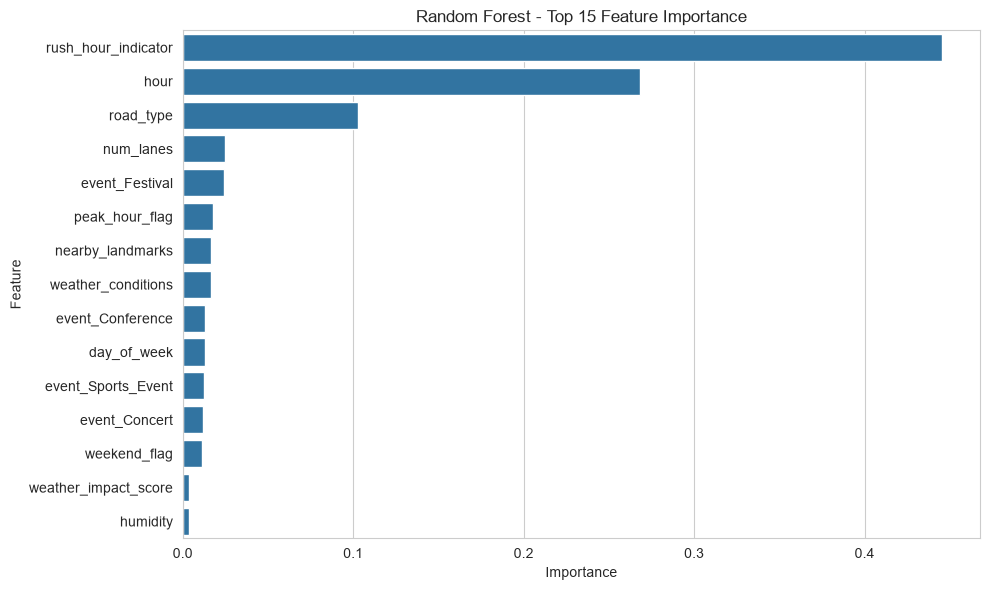

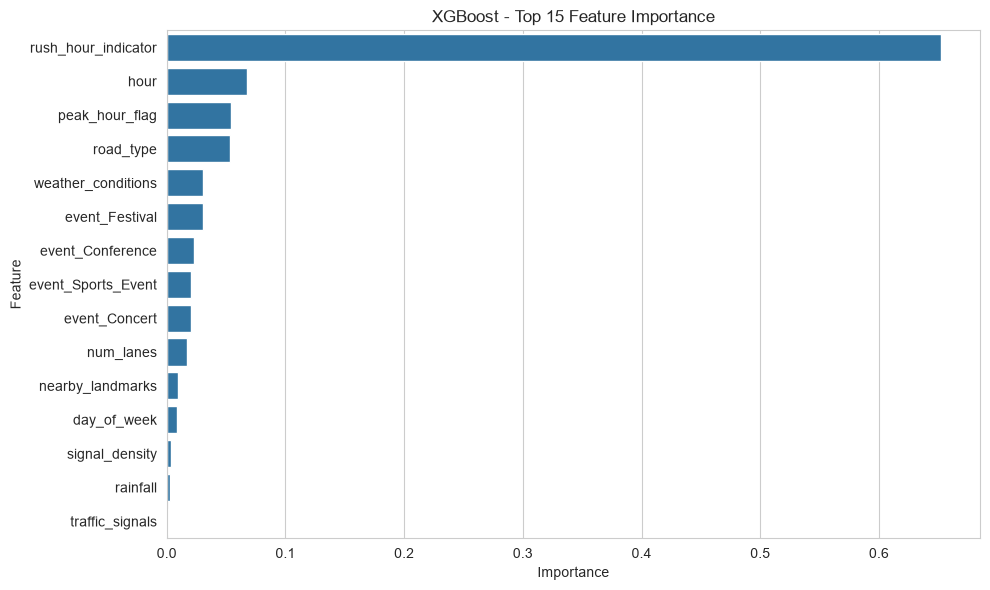

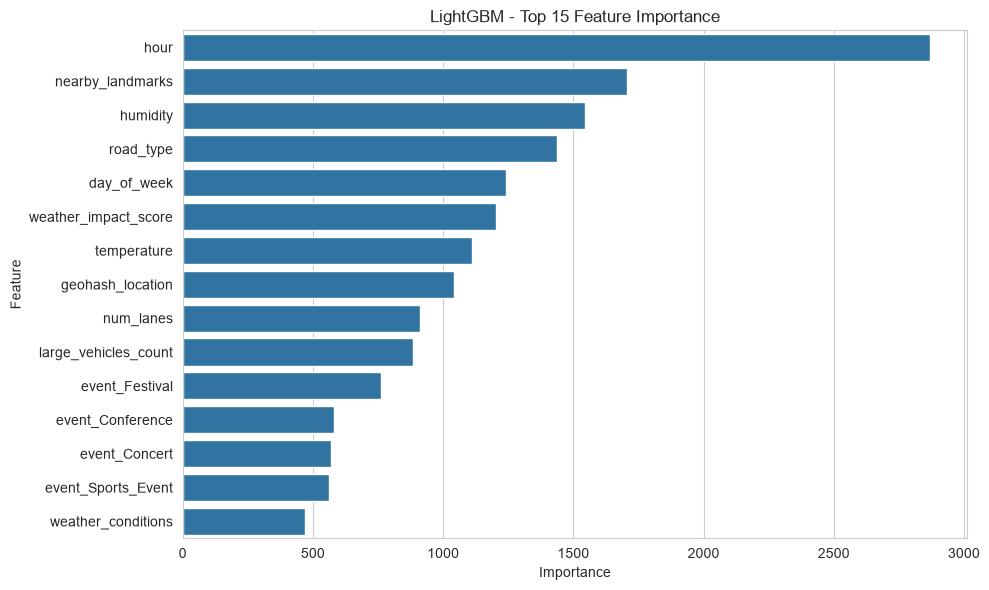

In [43]:
plot_feature_importance(
    rf,
    X_train.columns,
    "Random Forest"
)

plot_feature_importance(
    xgb,
    X_train.columns,
    "XGBoost"
)

plot_feature_importance(
    lgbm,
    X_train.columns,
    "LightGBM"
)

### Actual vs Predicted Traffic Demand Function

In [44]:
def plot_actual_vs_predicted(
    y_true,
    y_pred,
    model_name
):

    plt.figure(figsize=(7,7))

    plt.scatter(
        y_true,
        y_pred,
        alpha=0.4
    )

    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="red",
        linestyle="--",
        linewidth=2
    )

    plt.xlabel("Actual Traffic Demand")

    plt.ylabel("Predicted Traffic Demand")

    plt.title(f"{model_name} - Actual vs Predicted")

    plt.tight_layout()

    filename = (
        f"../visualizations/"
        f"{model_name.lower().replace(' ', '_')}_actual_vs_predicted.png"
    )

    plt.savefig(filename, dpi=300)

    plt.show()


### Generate Scatter Plots

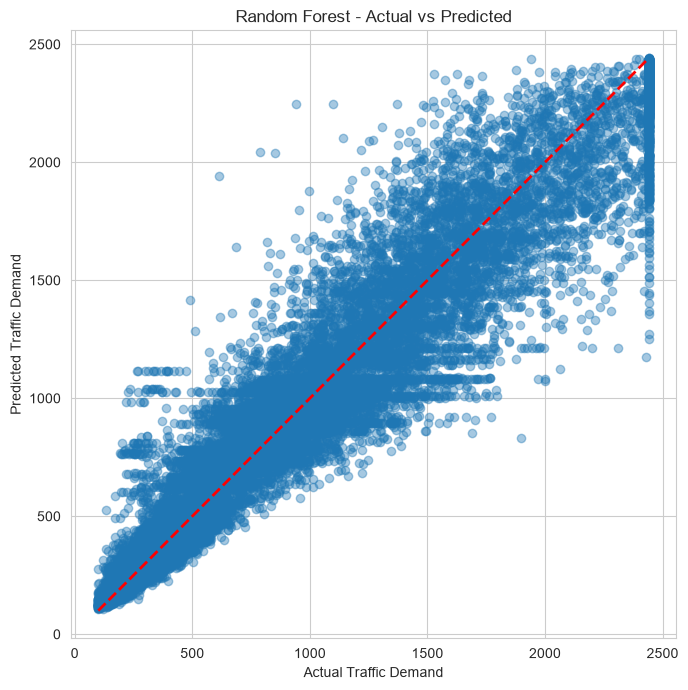

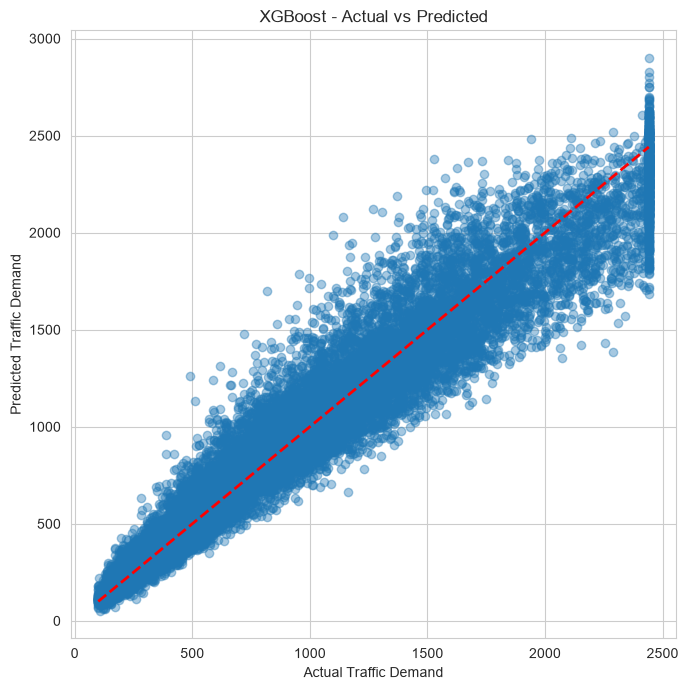

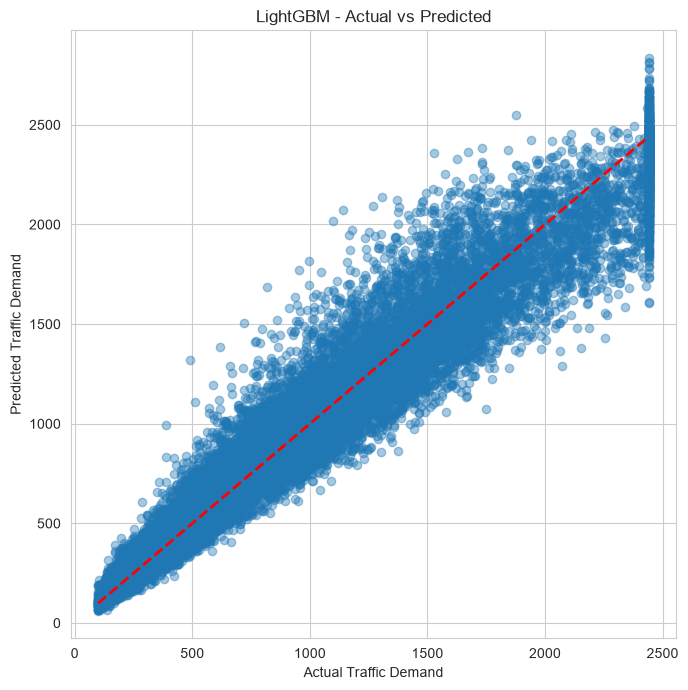

In [45]:
plot_actual_vs_predicted(
    y_test,
    rf_pred,
    "Random Forest"
)

plot_actual_vs_predicted(
    y_test,
    xgb_pred,
    "XGBoost"
)

plot_actual_vs_predicted(
    y_test,
    lgb_pred,
    "LightGBM"
)

### Top Features

In [46]:
models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

for name, model in models.items():

    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": model.feature_importances_
    })

    importance = (
        importance
        .sort_values("Importance", ascending=False)
        .head(15)
    )

    print("\n")
    print(name)
    display(importance)



Random Forest


,Feature,Importance
19,rush_hour_indicator,0.445427
0,hour,0.268307
3,road_type,0.102865
4,num_lanes,0.024691
15,event_Festival,0.024268
17,peak_hour_flag,0.017495
11,nearby_landmarks,0.016812
10,weather_conditions,0.016458
14,event_Conference,0.012824
1,day_of_week,0.012799




XGBoost


,Feature,Importance
19,rush_hour_indicator,0.652476
0,hour,0.067225
17,peak_hour_flag,0.053997
3,road_type,0.053400
10,weather_conditions,0.030710
15,event_Festival,0.030311
14,event_Conference,0.023325
16,event_Sports_Event,0.020736
13,event_Concert,0.020500
4,num_lanes,0.017462




LightGBM


,Feature,Importance
0,hour,2869
11,nearby_landmarks,1706
8,humidity,1543
3,road_type,1438
1,day_of_week,1240
21,weather_impact_score,1204
7,temperature,1111
2,geohash_location,1042
4,num_lanes,913
6,large_vehicles_count,886


## Hyperparameter Tuning

### Import

In [47]:
from sklearn.model_selection import RandomizedSearchCV

### XGBoost Paramter Grid

In [48]:
xgb_params = {
    "n_estimators": [200,300,400,500],
    "max_depth": [4,6,8,10],
    "learning_rate": [0.01,0.03,0.05,0.1],
    "subsample": [0.7,0.8,0.9,1.0],
    "colsample_bytree": [0.7,0.8,0.9,1.0]
}

### XGBoost Tuning Using RandomizedSearchCV

In [49]:
xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=xgb_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    verbose=1,

    random_state=42,

    n_jobs=-1
)

xgb_search.fit(
    X_train,
    y_train
)

best_xgb = xgb_search.best_estimator_

print("Best Parameters")
print(xgb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best Parameters
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.9}


### Evaluation Of Tuned Model

In [50]:
best_xgb_pred = best_xgb.predict(X_test)

xgb_tuned_results = evaluate_model(
    "XGBoost Tuned",
    y_test,
    best_xgb_pred
)

print(xgb_tuned_results)

{'Model': 'XGBoost Tuned', 'R² Score': 0.9482, 'RMSE': np.float64(143.6), 'MAE': 95.26, 'MAPE': np.float64(13.02)}


### LightGBM Parameter Grid

In [51]:
lgb_params = {
    "n_estimators":[200,300,400,500],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "num_leaves":[31,64,96,128],

    "max_depth":[5,8,10,-1],

    "subsample":[0.7,0.8,0.9,1.0]
}

### LightGBM Tuning (RandomizedSearchCV)

In [52]:
lgb_search = RandomizedSearchCV(
    estimator=LGBMRegressor(
        random_state=42
    ),

    param_distributions=lgb_params,

    n_iter=20,

    cv=5,

    scoring="r2",

    verbose=1,

    random_state=42,

    n_jobs=-1
)

lgb_search.fit(
    X_train,
    y_train
)

best_lgb = lgb_search.best_estimator_

print("Best Parameters")

print(lgb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1189
[LightGBM] [Info] Number of data points in the train set: 96000, number of used features: 22
[LightGBM] [Info] Start training from score 802.402849
Best Parameters
{'subsample': 0.8, 'num_leaves': 64, 'n_estimators': 400, 'max_depth': 10, 'learning_rate': 0.05}


### Evaluation of Tuned LightGBM

In [54]:
best_lgb_pred = best_lgb.predict(
    X_test
)

lgb_tuned_results = evaluate_model(
    "LightGBM Tuned",
    y_test,
    best_lgb_pred
)

print(lgb_tuned_results)

{'Model': 'LightGBM Tuned', 'R² Score': 0.9482, 'RMSE': np.float64(143.58), 'MAE': 95.04, 'MAPE': np.float64(13.0)}


### Comparison Table

In [55]:
final_results = pd.DataFrame([

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    ),

    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    ),

    xgb_tuned_results,

    evaluate_model(
        "LightGBM",
        y_test,
        lgb_pred
    ),

    lgb_tuned_results

])

final_results

,Model,R² Score,RMSE,MAE,MAPE
0,Random Forest,0.9207,177.60,115.47,16.06
1,XGBoost,0.9474,144.67,95.82,13.08
2,XGBoost Tuned,0.9482,143.60,95.26,13.02
3,LightGBM,0.9483,143.41,94.77,12.99
4,LightGBM Tuned,0.9482,143.58,95.04,13.00


In [56]:
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

joblib.dump(
    best_xgb,
    "../models/xgboost.pkl"
)

joblib.dump(
    best_lgb,
    "../models/lightgbm.pkl"
)


['../models/lightgbm.pkl']

In [57]:
print("\nFinal Model Performance")

display(
    final_results.sort_values(
        "R² Score",
        ascending=False
    )
)

best_model = final_results.sort_values(
    "R² Score",
    ascending=False
).iloc[0]

print("\nBest Model")

print(best_model["Model"])

print("R² Score :", best_model["R² Score"])

print("RMSE :", best_model["RMSE"])

print("MAE :", best_model["MAE"])

print("MAPE :", best_model["MAPE"])


Final Model Performance


,Model,R² Score,RMSE,MAE,MAPE
3,LightGBM,0.9483,143.41,94.77,12.99
4,LightGBM Tuned,0.9482,143.58,95.04,13.00
2,XGBoost Tuned,0.9482,143.60,95.26,13.02
1,XGBoost,0.9474,144.67,95.82,13.08
0,Random Forest,0.9207,177.60,115.47,16.06



Best Model
LightGBM
R² Score : 0.9483
RMSE : 143.41
MAE : 94.77
MAPE : 12.99
